# SLM vs LLM comparison — LoRA fine-tuning on Banking77

This notebook trains **two models** on the same task (classifying customer support
messages into one of 77 intents) and compares them:

- **SLM**: Qwen2.5-1.5B-Instruct (small model, full LoRA, no quantization needed)
- **LLM**: Qwen2.5-7B-Instruct (bigger model, QLoRA / 4-bit, so it fits on a free T4 GPU)

**How to use this notebook on Colab (free T4 GPU):**
1. Run the "Setup" and "Load data" sections once.
2. Set `WHICH_MODEL = "slm"` in the Config cell, then run everything down through
   the fine-tuning and evaluation sections.
3. Go to `Runtime > Restart runtime` (this fully frees the GPU memory).
4. Re-run "Setup" and "Load data" again, set `WHICH_MODEL = "llm"`, and run the
   fine-tuning and evaluation sections again.
5. Finally, run the **Comparison** section at the bottom — it only reads two
   small saved result files, so it works even in a brand new session.

This two-pass approach exists because a free T4 GPU (16GB) usually can't hold
both a 1.5B and a 7B model (plus training overhead) in memory at the same time.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install Unsloth first (important)
!pip install -q -U unsloth

# Install compatible versions for Unsloth (IMPORTANT: avoid latest TRL/Datasets)
!pip install -q \
datasets==4.3.0 \
trl==0.24.0 \
peft \
accelerate \
bitsandbytes \
evaluate \
scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6

## Config

Set `WHICH_MODEL` below to `"slm"` or `"llm"` depending on which pass you're doing.
Everything else in this notebook reads from this one setting, so you don't have
to hunt through cells and change things by hand each time.


In [3]:
import os

# ----- THE ONE THING YOU CHANGE BETWEEN PASSES -----
WHICH_MODEL = "llm"   # change to "llm" on your second pass through the notebook
# -----------------------------------------------------

if WHICH_MODEL == "slm":
    MODEL_NAME = "unsloth/Qwen2.5-1.5B-Instruct"
    LOAD_IN_4BIT = False     # small model, no need to quantize, fits fine as-is
    MAX_SEQ_LEN = 512
elif WHICH_MODEL == "llm":
    MODEL_NAME = "unsloth/Qwen2.5-7B-Instruct"
    LOAD_IN_4BIT = True      # bigger model, needs 4-bit (QLoRA) to fit on a T4
    MAX_SEQ_LEN = 512
else:
    raise ValueError("WHICH_MODEL must be 'slm' or 'llm'")

# Where to save results so the final comparison cell can read them back later,
# even in a different session
RESULTS_DIR = "/content/drive/MyDrive/SLM vs LLM"
os.makedirs(RESULTS_DIR, exist_ok=True)

# How much data to use. Classification tasks don't need huge amounts of data
# to learn a pattern, and less data = faster training on a free GPU.
N_TRAIN_EXAMPLES = 1500
N_TEST_EXAMPLES = 300   # keep test set smallish so evaluation doesn't take forever

print(f"Running pass for: {WHICH_MODEL}")
print(f"Model: {MODEL_NAME}, 4-bit: {LOAD_IN_4BIT}")


Running pass for: llm
Model: unsloth/Qwen2.5-7B-Instruct, 4-bit: True


## Step 1 — Load and prepare the dataset

We're using **Banking77**: short customer-support messages, each labeled with one
of 77 fine-grained intents (e.g. `card_not_working`, `exchange_rate`, ...).

This is a good task for this kind of comparison because:
- it has a clean, objective metric (accuracy / F1) — no messy text-generation scoring
- 77 classes is hard enough that a model can't get it right by just guessing
- it's narrow and specific, which is exactly where small fine-tuned models tend to
  catch up to much bigger ones


In [4]:
from datasets import load_dataset

# PolyAI/banking77 uses an old-style loading script, which newer versions of
# the datasets library no longer support. HF auto-converts script-based
# datasets to Parquet under this special branch — pointing at it avoids the error.
raw = load_dataset("PolyAI/banking77", revision="refs/convert/parquet")

# Get the human-readable label names (e.g. "card_not_working") instead of numbers
label_names = raw["train"].features["label"].names
print(f"Number of intents (classes): {len(label_names)}")
print("Example labels:", label_names[:5])

# Shuffle and take a manageable subset so training/eval stays fast on a free GPU
train_full = raw["train"].shuffle(seed=42)
test_full = raw["test"].shuffle(seed=42)

train_data = train_full.select(range(min(N_TRAIN_EXAMPLES, len(train_full))))
test_data = test_full.select(range(min(N_TEST_EXAMPLES, len(test_full))))

print(f"Using {len(train_data)} training examples and {len(test_data)} test examples")

print("\nExample:")
print("Text: ", train_data[0]["text"])
print("Label:", label_names[train_data[0]["label"]])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


0000.parquet:   0%|          | 0.00/298k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/93.9k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Number of intents (classes): 77
Example labels: ['activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up']
Using 1500 training examples and 300 test examples

Example:
Text:  A card payment on my account is shown as pending.
Label: pending_card_payment


## Step 2 — Turn this into a chat-style classification prompt

Both models are "instruct" models, so we talk to them using a chat template:
a system instruction (here are the 77 possible intents, pick one), then the
user message (the customer's text), and the model should reply with just the
intent label.

We use the SAME prompt format for both the SLM and the LLM, and for both the
"before fine-tuning" baseline and the "after fine-tuning" evaluation — so the
comparison stays fair and the only thing that changes between runs is the
model itself.


In [5]:
# Build the system prompt once — it lists all 77 possible labels so the model
# knows exactly what it's allowed to answer with.
LABEL_LIST_STR = ", ".join(label_names)

SYSTEM_PROMPT = (
    "You are a customer support intent classifier. "
    "Given a customer message, reply with ONLY the single most likely intent label "
    "from this exact list, and nothing else:\n"
    f"{LABEL_LIST_STR}"
)

def build_chat_messages(text, answer_label=None):
    """
    Builds a chat-format conversation for one example.
    If answer_label is given, it's included as the assistant's reply
    (used when building TRAINING data).
    If answer_label is None, the assistant turn is left empty
    (used at INFERENCE/evaluation time — the model has to fill it in).
    """
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": text},
    ]
    if answer_label is not None:
        messages.append({"role": "assistant", "content": answer_label})
    return messages


def parse_predicted_label(generated_text):
    """
    The model's raw output is free text. We match it against our known label
    list to turn it into a clean label we can score. If nothing matches, we
    return 'unknown' so it just counts as a wrong answer instead of crashing.
    """
    cleaned = generated_text.strip().lower()
    # Exact match first
    for name in label_names:
        if cleaned == name.lower():
            return name
    # Otherwise, look for a label name contained somewhere in the output
    for name in label_names:
        if name.lower() in cleaned:
            return name
    return "unknown"


## Step 3 — Load the model (with Unsloth)

`FastLanguageModel.from_pretrained` loads the base model. Unsloth handles the
4-bit loading and memory optimizations for us automatically — we just tell it
which model to load and whether to quantize it.


In [6]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LEN,
    load_in_4bit=LOAD_IN_4BIT,
    dtype=None,  # let unsloth pick the best dtype for your GPU automatically
)

print("Model loaded:", MODEL_NAME)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json:   0%|          | 0.00/112k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-7b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Model loaded: unsloth/Qwen2.5-7B-Instruct


## Step 4 — Baseline: how good is the model BEFORE any fine-tuning?

This number matters a lot — without it, we can't say how much fine-tuning
actually helped. We run the un-tuned model on the test set first, before
touching LoRA at all.


In [7]:
from sklearn.metrics import accuracy_score, f1_score
import time

def evaluate_model(model, tokenizer, dataset, max_new_tokens=12, desc=""):
    """
    Runs the model on every example in `dataset` and scores it.
    Returns a dict with accuracy, macro-F1, and average latency per example.
    This same function is used for baseline AND fine-tuned evaluation, and for
    both models, so every score in this notebook is computed the exact same way.
    """
    FastLanguageModel.for_inference(model)  # switches the model into fast inference mode

    true_labels = []
    pred_labels = []
    latencies = []

    for example in dataset:
        text = example["text"]
        true_label = label_names[example["label"]]

        messages = build_chat_messages(text)  # no answer included — model must predict
        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        start = time.time()
        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,         # deterministic output, fairer comparison
                pad_token_id=tokenizer.eos_token_id,
            )
        latencies.append(time.time() - start)

        # Only decode the NEW tokens (the model's answer), not the prompt we fed in
        new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
        generated_text = tokenizer.decode(new_tokens, skip_special_tokens=True)

        pred_label = parse_predicted_label(generated_text)

        true_labels.append(true_label)
        pred_labels.append(pred_label)

    accuracy = accuracy_score(true_labels, pred_labels)
    macro_f1 = f1_score(true_labels, pred_labels, average="macro", zero_division=0)
    avg_latency_ms = (sum(latencies) / len(latencies)) * 1000

    result = {
        "description": desc,
        "model": MODEL_NAME,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "avg_latency_ms": avg_latency_ms,
        "n_test_examples": len(dataset),
    }
    print(f"[{desc}] accuracy={accuracy:.3f}  macro_f1={macro_f1:.3f}  "
          f"avg latency={avg_latency_ms:.1f}ms")
    return result


# Run this BEFORE fine-tuning, so we have a "starting point" score to compare against
baseline_result = evaluate_model(
    model, tokenizer, test_data,
    desc=f"{WHICH_MODEL}_baseline_zero_shot"
)


Both `max_new_tokens` (=12) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/

[llm_baseline_zero_shot] accuracy=0.630  macro_f1=0.572  avg latency=839.5ms


## Step 5 — Add LoRA adapters and fine-tune

Instead of updating all of the model's weights (slow, needs lots of memory),
LoRA adds small trainable "adapter" matrices into the attention layers and
only trains those. This is what makes fine-tuning possible on a free GPU.

We use the SAME LoRA settings (rank, alpha, target layers, learning rate,
epochs) for both the SLM and LLM passes, so the comparison stays fair — the
only real difference between the two runs is the model itself.


In [8]:
# --- Add LoRA adapters to the model ---
model = FastLanguageModel.get_peft_model(
    model,
    r=16,                  # LoRA rank — higher = more capacity to learn, more memory used
    lora_alpha=32,          # scaling factor, commonly set to 2x the rank
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
    use_gradient_checkpointing="unsloth",  # saves memory, important on a T4
    random_state=42,
)

# Report how many parameters we're actually training — this number is itself
# part of the comparison story (SLM vs LLM trainable %).
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_params:,} / {total_params:,} "
      f"({100 * trainable_params / total_params:.3f}%)")

# --- Format the training data as text the model can learn from ---
def format_training_example(example):
    text = example["text"]
    answer = label_names[example["label"]]
    messages = build_chat_messages(text, answer_label=answer)
    formatted = tokenizer.apply_chat_template(messages, tokenize=False)
    return {"text": formatted}

train_formatted = train_data.map(format_training_example)

print("\nExample of a formatted training row (this is what the model actually sees):")
print(train_formatted[0]["text"])


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.6.8 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Trainable params: 10,092,544 / 4,901,639,680 (0.206%)


Map:   0%|          | 0/1500 [00:00<?, ? examples/s]


Example of a formatted training row (this is what the model actually sees):
<|im_start|>system
You are a customer support intent classifier. Given a customer message, reply with ONLY the single most likely intent label from this exact list, and nothing else:
activate_my_card, age_limit, apple_pay_or_google_pay, atm_support, automatic_top_up, balance_not_updated_after_bank_transfer, balance_not_updated_after_cheque_or_cash_deposit, beneficiary_not_allowed, cancel_transfer, card_about_to_expire, card_acceptance, card_arrival, card_delivery_estimate, card_linking, card_not_working, card_payment_fee_charged, card_payment_not_recognised, card_payment_wrong_exchange_rate, card_swallowed, cash_withdrawal_charge, cash_withdrawal_not_recognised, change_pin, compromised_card, contactless_not_working, country_support, declined_card_payment, declined_cash_withdrawal, declined_transfer, direct_debit_payment_not_recognised, disposable_card_limits, edit_personal_details, exchange_charge, exchange_ra

In [9]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir=f"{RESULTS_DIR}/{WHICH_MODEL}_checkpoints",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,   # effective batch size = 4 x 4 = 16
    num_train_epochs=3,
    learning_rate=2e-4,
    warmup_ratio=0.05,
    logging_steps=10,
    save_strategy="no",              # we save the final adapter manually below instead
    report_to="none",
    max_seq_length=MAX_SEQ_LEN,
    dataset_text_field="text",
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_formatted,
    args=training_args,
)

train_result = trainer.train()
print("Training finished.")
print("Final training loss:", train_result.training_loss)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1500 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,500 | Num Epochs = 3 | Total steps = 282
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 10,092,544 of 7,625,709,056 (0.13% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
10,2.498559
20,1.596242
30,0.365909
40,0.117192
50,0.085145
60,0.089428
70,0.081501
80,0.081815
90,0.076605
100,0.078799


Training finished.
Final training loss: 0.2287475403319014


## Step 6 — Evaluate AFTER fine-tuning

Same `evaluate_model` function as before, same test set, same prompt format.
The only thing that changed is the model now has LoRA adapters trained on our
banking intent data.


In [10]:
finetuned_result = evaluate_model(
    model, tokenizer, test_data,
    desc=f"{WHICH_MODEL}_finetuned_lora"
)

# Save the LoRA adapter itself (a small file — just the adapter weights, not the
# whole base model)
model.save_pretrained(f"{RESULTS_DIR}/{WHICH_MODEL}_lora_adapter")
tokenizer.save_pretrained(f"{RESULTS_DIR}/{WHICH_MODEL}_lora_adapter")

# Save all the numbers to a JSON file so the final comparison cell (which may
# run in a totally separate session, after a runtime restart) can read them back
import json

summary = {
    "which_model": WHICH_MODEL,
    "model_name": MODEL_NAME,
    "load_in_4bit": LOAD_IN_4BIT,
    "trainable_params": trainable_params,
    "total_params": total_params,
    "trainable_pct": 100 * trainable_params / total_params,
    "baseline": baseline_result,
    "finetuned": finetuned_result,
}

with open(f"{RESULTS_DIR}/{WHICH_MODEL}_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"\nSaved results to {RESULTS_DIR}/{WHICH_MODEL}_summary.json")
print(json.dumps(summary, indent=2))


Both `max_new_tokens` (=12) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=12

[llm_finetuned_lora] accuracy=0.833  macro_f1=0.784  avg latency=814.3ms


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/SLM vs LLM/llm_lora_adapter/tokenizer_config.json.



Saved results to /content/drive/MyDrive/SLM vs LLM/llm_summary.json
{
  "which_model": "llm",
  "model_name": "unsloth/Qwen2.5-7B-Instruct",
  "load_in_4bit": true,
  "trainable_params": 10092544,
  "total_params": 4901639680,
  "trainable_pct": 0.20590138522789175,
  "baseline": {
    "description": "llm_baseline_zero_shot",
    "model": "unsloth/Qwen2.5-7B-Instruct",
    "accuracy": 0.63,
    "macro_f1": 0.5719296462632074,
    "avg_latency_ms": 839.5466550191244,
    "n_test_examples": 300
  },
  "finetuned": {
    "description": "llm_finetuned_lora",
    "model": "unsloth/Qwen2.5-7B-Instruct",
    "accuracy": 0.8333333333333334,
    "macro_f1": 0.783764084146055,
    "avg_latency_ms": 814.301016330719,
    "n_test_examples": 300
  }
}


## Now repeat for the other model

If `WHICH_MODEL` was `"slm"` above:
1. `Runtime > Restart runtime` (this fully clears the GPU)
2. Scroll back up to the **Config** cell, set `WHICH_MODEL = "llm"`
3. Run every cell again from the top, in order, down through Step 6

Once you have both `slm_summary.json` and `llm_summary.json` saved in
`/content/results`, run the comparison section below.


## Step 7 — Compare SLM vs LLM

This part only needs the two saved JSON summary files — it doesn't need either
model loaded in memory, so it's safe to run in a brand new session.


In [12]:
import json
import pandas as pd

RESULTS_DIR = "/content/drive/MyDrive/SLM vs LLM"  # re-set in case this is a fresh session

with open(f"{RESULTS_DIR}/slm_summary.json") as f:
    slm = json.load(f)
with open(f"{RESULTS_DIR}/llm_summary.json") as f:
    llm = json.load(f)

rows = []
for label, data in [("SLM", slm), ("LLM", llm)]:
    rows.append({
        "model": f"{label} ({data['model_name']})",
        "trainable_params_%": round(data["trainable_pct"], 3),
        "baseline_accuracy": round(data["baseline"]["accuracy"], 3),
        "finetuned_accuracy": round(data["finetuned"]["accuracy"], 3),
        "accuracy_gain": round(
            data["finetuned"]["accuracy"] - data["baseline"]["accuracy"], 3
        ),
        "finetuned_macro_f1": round(data["finetuned"]["macro_f1"], 3),
        "avg_latency_ms": round(data["finetuned"]["avg_latency_ms"], 1),
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))
comparison_df.to_csv(f"{RESULTS_DIR}/comparison_table.csv", index=False)


                              model  trainable_params_%  baseline_accuracy  finetuned_accuracy  accuracy_gain  finetuned_macro_f1  avg_latency_ms
SLM (unsloth/Qwen2.5-1.5B-Instruct)               0.282               0.48               0.670          0.190               0.619           311.0
  LLM (unsloth/Qwen2.5-7B-Instruct)               0.206               0.63               0.833          0.203               0.784           814.3


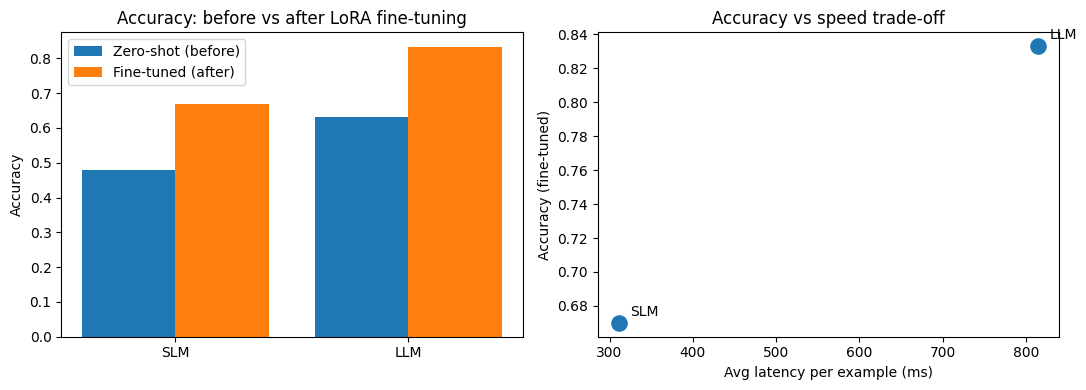

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left plot: accuracy before vs after fine-tuning, for each model
labels = comparison_df["model"]
x = range(len(labels))
axes[0].bar([i - 0.2 for i in x], comparison_df["baseline_accuracy"], width=0.4, label="Zero-shot (before)")
axes[0].bar([i + 0.2 for i in x], comparison_df["finetuned_accuracy"], width=0.4, label="Fine-tuned (after)")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(["SLM", "LLM"])
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy: before vs after LoRA fine-tuning")
axes[0].legend()

# Right plot: the actual trade-off — accuracy vs latency
axes[1].scatter(comparison_df["avg_latency_ms"], comparison_df["finetuned_accuracy"], s=120)
for i, row in comparison_df.iterrows():
    axes[1].annotate(["SLM", "LLM"][i], (row["avg_latency_ms"], row["finetuned_accuracy"]),
                      textcoords="offset points", xytext=(8, 5))
axes[1].set_xlabel("Avg latency per example (ms)")
axes[1].set_ylabel("Accuracy (fine-tuned)")
axes[1].set_title("Accuracy vs speed trade-off")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/comparison_plot.png", dpi=150)
plt.show()


## How to read your results

- **Accuracy gain** shows how much LoRA fine-tuning helped each model. If the
  SLM's gain is much bigger than the LLM's, that supports the idea that small
  models benefit more from task-specific fine-tuning (they had more room to
  improve).
- **Finetuned accuracy gap** between SLM and LLM, after both are fine-tuned,
  is your headline number — "how close did the small model get?"
- **Latency** is the cost side of the trade-off. Even if the LLM scores a bit
  higher, the SLM being several times faster might make it the better
  real-world choice for this task.
- The right-hand scatter plot is a good single "so what" chart for a write-up
  — it directly shows the accuracy-vs-speed trade-off between the two models.

### Ideas to extend this project
- Vary `N_TRAIN_EXAMPLES` (e.g. 200, 500, 1000, 2000) and re-run to see how
  each model's accuracy scales with the amount of fine-tuning data.
- Try a different LoRA rank (`r=8` vs `r=32`) to see how much it matters.
- Add a third model size from the same family for a 3-point scaling curve.
- Pull out 5-10 examples both models got wrong and read them by hand — this
  kind of qualitative error review is usually the most interesting part of
  these comparisons.
